In [1]:
import polars as pl
import torch
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import Lasso
import numpy as np
from amaretto_mlp import *
from utils_b import *
from autoencoder import *
from explanation import *

%matplotlib inline
%load_ext autoreload
%autoreload 2

# 1. Data & model preperatiom

In [2]:
pl.Config.set_tbl_cols(150) 

polars.config.Config

In [3]:
df = pl.read_parquet("amaretto_transformed_scaled.pq")
df = df.with_columns(((pl.col('hour') >= 1) & (pl.col('hour') < 6)).alias('unusual_hour'))
df_train, df_val, df_test = split_data(df)

#columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime']
#columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime', 'day_of_week', 'day_of_month', 'hour', 'minute']
columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime', 'day_of_week', 'day_of_month', 'hour', 'minute', 'day_of_week_cos', 'day_of_month_cos', 'minute_cos', 'day_of_week_sin', 'day_of_month_sin', 'minute_sin']


target_column = 'Anomaly'
y_train = df_train.select(target_column).to_numpy().flatten()
df_train = df_train.drop(columns_to_drop)
X_train = df_train.to_numpy()
y_val = df_val.select(target_column).to_numpy().flatten()
X_val = df_val.drop(columns_to_drop).to_numpy()
y_test = df_test.select(target_column).to_numpy().flatten()
X_test = df_test.drop(columns_to_drop).to_numpy()

train_dataset = AmarettoDataset(X_train, y_train)
val_dataset = AmarettoDataset(X_val, y_val)
test_dataset = AmarettoDataset(X_test, y_test)
feature_names = df_train.columns
print(X_train.shape)
print(X_test.shape)

(24451934, 116)
(2765755, 116)


In [4]:
train_loader = DataLoader(train_dataset, batch_size=256, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=256, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=256, num_workers=2)
input_dim = X_train.shape[1]
df_train, df_val, df_test = split_data(df)
print(len(train_loader))

95516


In [5]:
model = CombinedModel(input_dim=X_train.shape[1], hidden_layers=[64, 64], latent_dim=16, num_classes=6)
model.load_state_dict(torch.load("model_combined_3.pth"))
print(model)

CombinedModel(
  (encoder): Encoder(
    (network): Sequential(
      (0): Linear(in_features=116, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=16, bias=True)
    )
  )
  (decoder): Decoder(
    (network): Sequential(
      (0): Linear(in_features=16, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=116, bias=True)
    )
  )
  (classifier): Classifier(
    (network): Sequential(
      (0): Linear(in_features=16, out_features=16, bias=True)
      (1): ReLU()
      (2): Linear(in_features=16, out_features=6, bias=True)
    )
  )
)


In [ ]:
model.eval()
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
with torch.no_grad():
    _, y_pred_train, z_train = model(X_train_tensor)
    y_pred_train = torch.argmax(y_pred_train, dim=1)
y_pred_train = y_pred_train.cpu().detach().numpy()
print(y_pred_train.shape)
z_train = z_train.cpu().numpy()
print(z_train.shape)

In [ ]:
model.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
with torch.no_grad():
    _, y_pred_test, z_test = model(X_test_tensor)
    y_pred_test = torch.argmax(y_pred_test, dim=1)
y_pred_test = y_pred_test.cpu().detach().numpy()
print(y_pred_test.shape)
z_test = z_test.cpu().numpy()
print(z_test.shape)

In [ ]:
df_test = df_test.with_columns(pl.Series("Model Prediction", y_pred_test))
df_test = df_test.select(["Model Prediction", *df_test.columns[:-1]])  
df_test = df_test.with_row_index(name="index")
df_test

In [ ]:
df_train = df_train.with_columns(pl.Series("Model Prediction", y_pred_train))
df_train = df_train.select(["Model Prediction", *df_train.columns[:-1]])  
df_train = df_train.with_row_index(name="index")
df_train

In [ ]:
print(classification_report(y_test, y_pred_test))

In [ ]:
print(confusion_matrix(y_test, y_pred_test))

In [ ]:
mask_correct_preds = (y_test[y_test != 0] == y_pred_test[y_test != 0])
mask_wrong_preds = (y_test[y_test != 0] != y_pred_test[y_test != 0])
print(mask_correct_preds.sum())
print(mask_wrong_preds.sum())

In [ ]:
df_correct_preds = df_test.filter((pl.col("Anomaly") != 0))
df_correct_preds = df_correct_preds.filter(mask_correct_preds)
df_wrong_preds = df_test.filter((pl.col("Anomaly") != 0))
df_wrong_preds = df_wrong_preds.filter(mask_wrong_preds)
print(df_correct_preds.height)
print(df_wrong_preds.height)

# 2. Explanations on input space

In [ ]:
X_train_n = X_train[y_pred_train == 0]
y_train_n = y_pred_train[y_pred_train == 0]
print(X_train_n.shape)
print(y_train_n.shape)

## 2.1. Small but highly frequent transactions generated within a short timeframe:
A pattern that contains multiple transactions below applicable reporting thresholds.  


In [447]:
anomaly_type = 1
#idx = 8357
idx = 38329

In [448]:
X_train_a = X_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(X_train_a.shape)
print(y_train_a.shape)

(26277, 116)
(26277,)


In [449]:
# z_train_n = z_train[y_train == 0]
# y_train_n = y_pred_train[y_pred_train == 0]
# z_train_a = z_train[y_pred_train == anomaly_type]
# y_train_a = y_pred_train[y_pred_train == anomaly_type]

In [450]:
# x = torch.tensor(X_test[idx], dtype=torch.float32).reshape(1, -1)
x = X_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

# model.encoder.eval()
# test_transaction_latent = model.encoder(x)
# test_transaction_latent = test_transaction_latent.cpu().detach().numpy()
# test_transaction_latent = test_transaction_latent.reshape(1, -1)
# test_transaction_latent.shape

(1, 116)
[[-1.44874071  0.          1.          0.          1.          0.        ]]
1
1


In [451]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator,unusual_hour
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
38329,1,26944892,2019-03-18 08:01:16,"""Client_389""",1,1,-1.448741,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,1,18,8,1,false,2.054952,1.690853,1.400966,1.251966,1.166733,-0.669069,-0.284955,-0.112912,0.0,0.0,1.037127,-0.917766,-0.698787,-0.576665,-0.484611,-0.433523,-0.183119,-0.071133,0.0,0.0,0.549258,-0.000208,0.646075,0.000056,0.71708,1.365456,0.513469,-1.287407,-1.364252,0.64142,0.000044,1.413977,0.344561,0.199322,0.2127,-0.933059,0.123479,-2.250

In [403]:
lasso_x_train, lasso_y_train = find_knn(x, X_train_n, y_train_n, X_train_a, y_train_a, k=21)

(42, 116)
(42,)


In [25]:
#df_train.filter(pl.col('Anomaly') == 0)[indices_n.flatten().tolist()]
#df_train.filter(pl.col('Anomaly') == 1)[indices_a.flatten().tolist()]

In [404]:
lasso_classifier = Lasso(alpha=0.01)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
#print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

Lasso(alpha=0.01)

In [405]:
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[  0  25  22  59  73 112  57 114  23  69]
num of non-zero features: 22
amount_log: -0.21403175149689746
Product Class_Cash in / out (withdrawal), Security in / out: 0.19501150482310747
Product Type_Repo: -0.18959751815224715
rolling_mean_24h: -0.1347835864282306
rolling_min_1h: 0.1110312311057298
Product Type_freq_originator: 0.11000783996426312
rolling_mean_1h: -0.09355838573502091
Currency_freq_originator: 0.05593438556091587
Product Type_SimpleTransfer: 0.05445025640835621
rolling_max_1h: -0.03708660145117437


[ 4837  2078  9758 26386 24820]


Using 2998 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 116, 6)
1


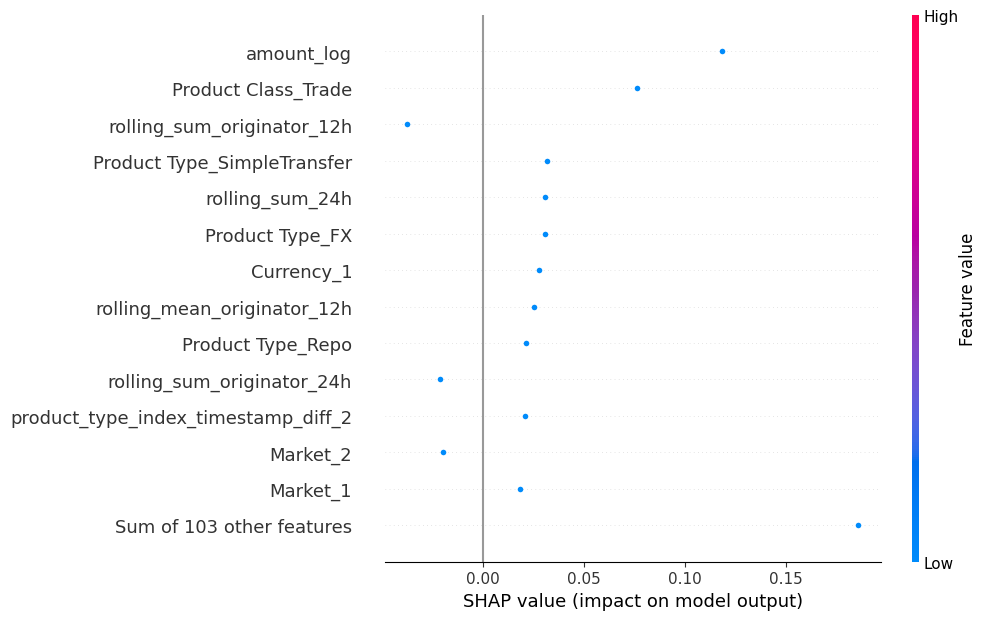

<Figure size 640x480 with 0 Axes>

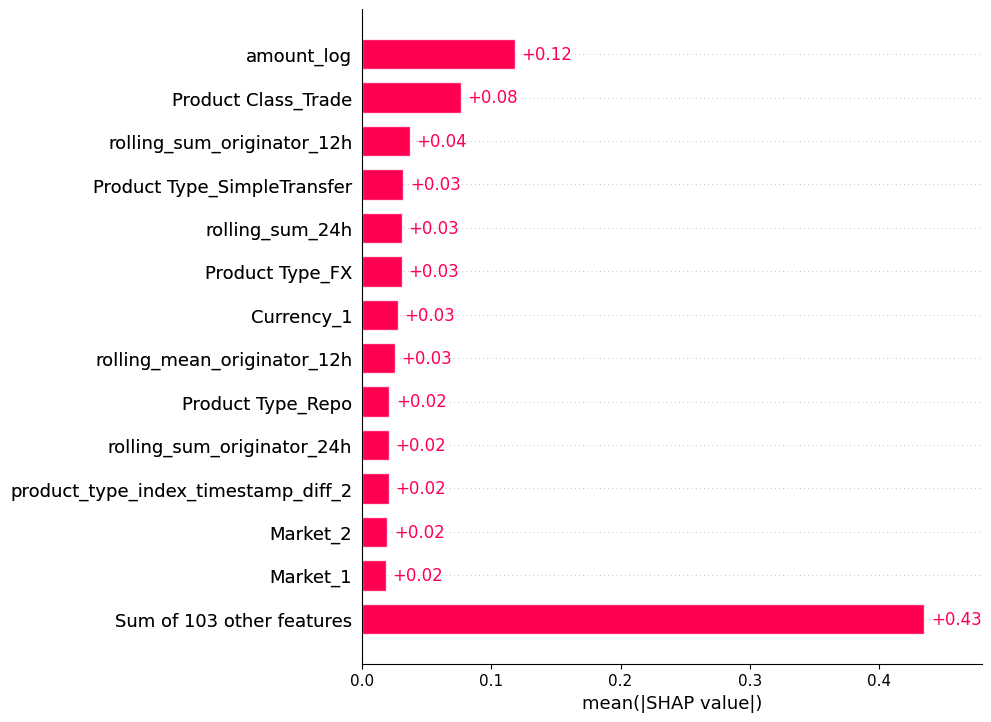

Saved SHAP plots for class 1 to output/shap_plots/
SHAP explanations generated and saved.


In [452]:
X_train_shap, _, _ = sample_data(X_train, y_train, n_samples=3000, anomaly_ratio=0.3, random_seed=42)
get_shap_explanations_mlp_class(model, X_train_shap, x.reshape(1, -1), feature_names, filename='figs/shap_plots/shap_amaretto_GM')


In [406]:
imp_features = [feature_names[idx] for idx in sorted_importance]
print(imp_features)
df_test.filter(pl.col('index') == idx).select(imp_features)

['amount_log', 'Product Class_Cash in / out (withdrawal), Security in / out', 'Product Type_Repo', 'rolling_mean_24h', 'rolling_min_1h', 'Product Type_freq_originator', 'rolling_mean_1h', 'Currency_freq_originator', 'Product Type_SimpleTransfer', 'rolling_max_1h']


amount_log,"Product Class_Cash in / out (withdrawal), Security in / out",Product Type_Repo,rolling_mean_24h,rolling_min_1h,Product Type_freq_originator,rolling_mean_1h,Currency_freq_originator,Product Type_SimpleTransfer,rolling_max_1h
f64,u8,u8,f64,f64,f64,f64,f64,u8,f64
-1.448741,1,0,0.2127,0.354526,0.6808,0.344561,-1.602753,1,-0.272026


In [407]:
y_pred = lasso_classifier.predict(x.reshape(1, -1))
print(y_pred)
print('R squared training set', lasso_classifier.score(lasso_x_train, lasso_y_train))

[0.64017149]
R squared training set 0.896426635408231


In [408]:
lasso_classifier = Lasso(alpha=0.05)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)
#print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

[  0  23  25 114  59  41  73  76 111 110]
num of non-zero features: 8
amount_log: -0.2129889556128491
Product Type_SimpleTransfer: 0.13211117263012104
Product Class_Cash in / out (withdrawal), Security in / out: 0.09916837994376143
Currency_freq_originator: 0.09044407296963013
rolling_mean_24h: -0.07660726019805852
product_type_index_timestamp_diff_1: -0.040417973285046496
rolling_min_1h: 0.031736266201419026
rolling_min_7d: -0.003822881933573109
Market_freq_originator: -0.0
InputOutput_freq_originator: 0.0


## 2.2. Transactions with rounded normalized amounts bought or sold within an account:
It is unusual for transactions in capital markets to have rounded amounts (unless they occur in markets where foreign exchange conversion causes rounding errors).  


In [525]:
anomaly_type = 2
#idx = 2762998
idx = 8891

In [526]:
X_train_a = X_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(X_train_a.shape)
print(y_train_a.shape)

(8768, 116)
(8768,)


In [527]:
x = X_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

(1, 116)
[[-0.19020766  0.          1.          1.          0.          0.        ]]
2
2


In [528]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator,unusual_hour
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
8891,2,27013699,2019-03-18 07:08:31,"""Client_066""",2,1,-0.190208,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,18,7,8,true,2.694246,1.938714,1.604807,1.429491,1.326428,-0.669069,-0.284955,-0.112912,0.0,0.0,-1.390533,-0.917766,-0.698787,-0.576665,-0.484611,-0.433523,-0.183119,-0.071133,0.0,0.0,0.89806,-0.000208,-0.000167,0.000056,0.71708,1.365456,0.513469,-1.287407,-1.409974,1.270989,-0.946266,1.050736,-1.469272,-3.17115,-3.764227,-0.91711,-3.313611,-

In [529]:
lasso_x_train, lasso_y_train = find_knn(x, X_train_n, y_train_n, X_train_a, y_train_a, k=21)

(42, 116)
(42,)


In [530]:
lasso_classifier = Lasso(alpha=0.01)
lasso_classifier.fit(lasso_x_train, lasso_y_train)

Lasso(alpha=0.01)

In [504]:
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[ 30 110 113 115 112 111 109 108 107 106]
num of non-zero features: 2
is_rounded: 1.9551532289126867
InputOutput_freq_originator: 0.002909954221497724
Product Class_freq_originator: -0.0
unusual_hour: 0.0
Product Type_freq_originator: 0.0
Market_freq_originator: 0.0
cumcount_Currency: -0.0
cumcount_Product Class: -0.0
cumcount_Product Type: -0.0
cumcount_Market: 0.0


[ 4837  2078  9758 26386 24820]


Using 2998 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 116, 6)
2


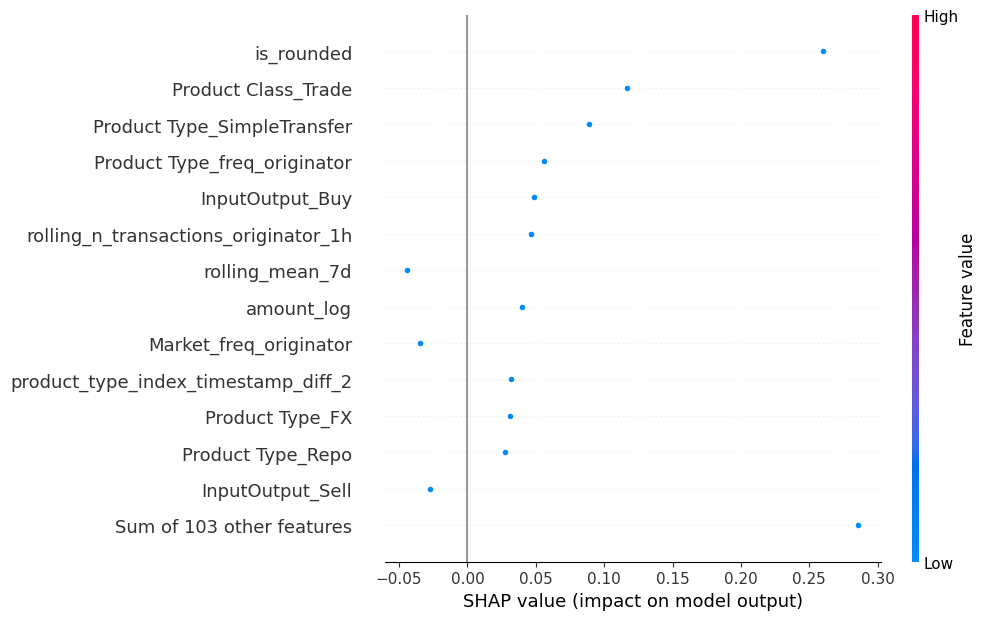

<Figure size 640x480 with 0 Axes>

Saved SHAP plots for class 2 to output/shap_plots/
SHAP explanations generated and saved.


In [507]:
X_train_shap, _, _ = sample_data(X_train, y_train, n_samples=3000, anomaly_ratio=0.3, random_seed=42)
get_shap_explanations_mlp_class(model, X_train_shap, x.reshape(1, -1), feature_names, filename='figs/shap_plots/shap_amaretto_GM')


In [ ]:
#get_shap_explanations_mlp_class(model, lasso_x_train, x.reshape(1, -1), feature_names, filename='figs/shap_plots/shap_amaretto_GM')


In [531]:
# 8891, # k = 21
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[ 25 113  41   0 110  27 109 108 112 111]
num of non-zero features: 6
Product Class_Cash in / out (withdrawal), Security in / out: 1.9287864377690793
Product Class_freq_originator: -0.016535760743422227
product_type_index_timestamp_diff_1: 0.0032949164210060496
amount_log: -0.002477119917853155
InputOutput_freq_originator: 0.0018858644290279012
Product Class_Trade: -4.2875755855762e-15
cumcount_Currency: -0.0
cumcount_Product Class: -0.0
Product Type_freq_originator: 0.0
Market_freq_originator: -0.0


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 116, 6)
2


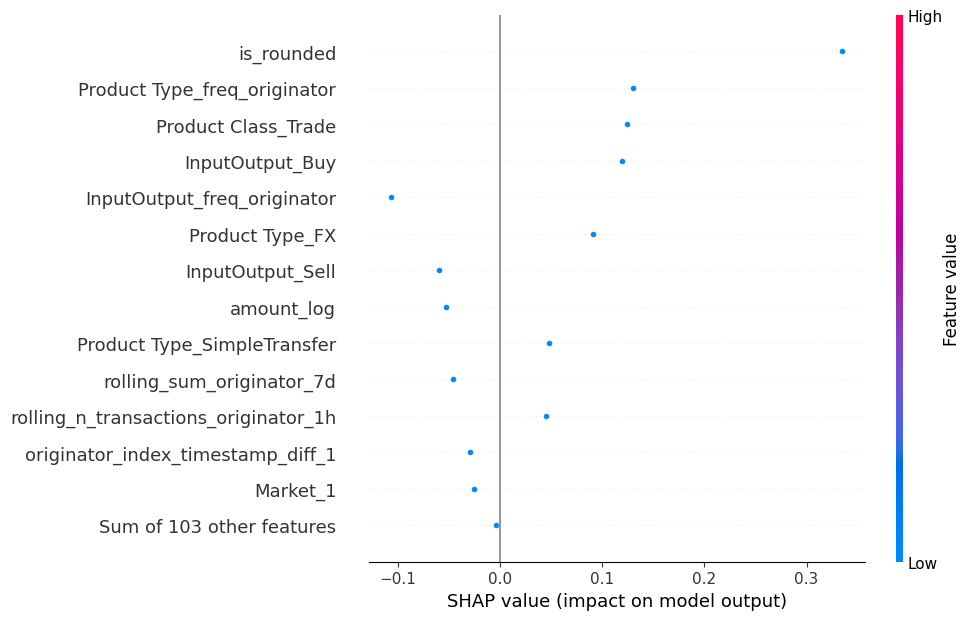

<Figure size 640x480 with 0 Axes>

Saved SHAP plots for class 2 to output/shap_plots/
SHAP explanations generated and saved.


In [532]:
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_amaretto_GM')

In [520]:
# 8891, # k = 210
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[ 25  23   1  30   0  63  32 106  89  69]
num of non-zero features: 22
Product Class_Cash in / out (withdrawal), Security in / out: 0.8192568835279064
Product Type_SimpleTransfer: 0.23879301963828384
InputOutput_Buy: -0.23841726717888176
is_rounded: 0.233682825460571
amount_log: -0.18062751310425412
rolling_sum_24h: 0.13505326637444512
originator_index_timestamp_diff_2: -0.10132539026083744
cumcount_Market: -0.08567980268926786
rolling_max_originator_1h: -0.06207979995310566
rolling_max_1h: -0.04800559555179255


[ 4837  2078  9758 26386 24820]


Using 2998 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 116, 6)
2


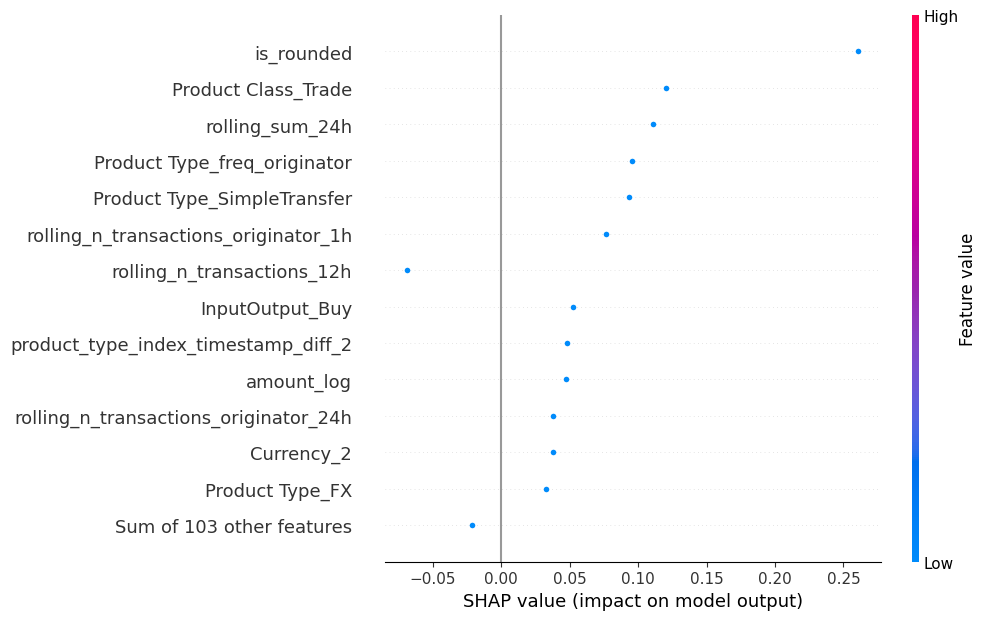

<Figure size 640x480 with 0 Axes>

Saved SHAP plots for class 2 to output/shap_plots/
SHAP explanations generated and saved.


In [521]:
get_shap_explanations_mlp_class(model, X_train_shap, x, feature_names, filename='figs/shap_plots/shap_amaretto_GM')


Using 420 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 116, 6)
2


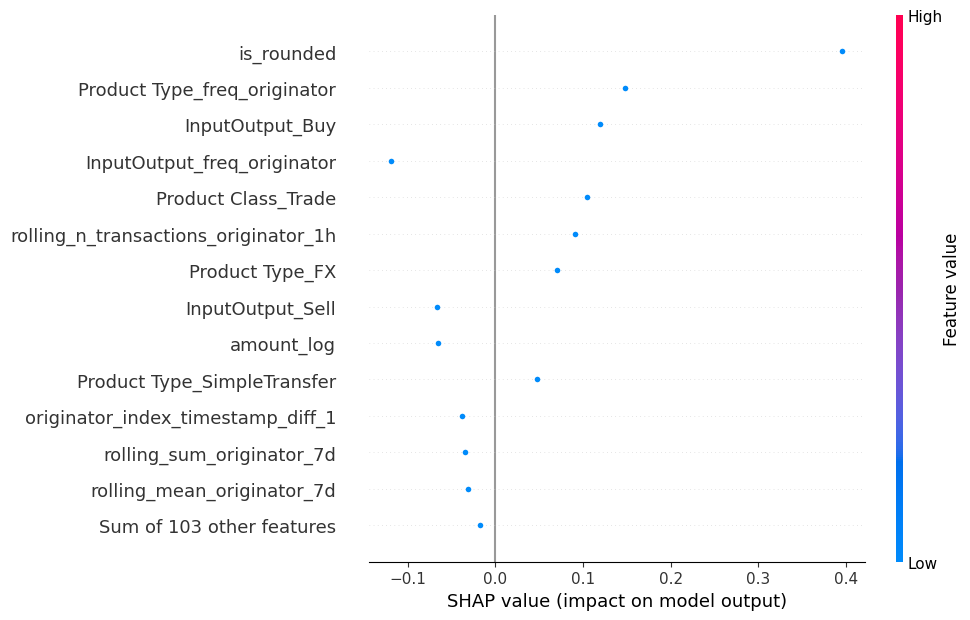

<Figure size 640x480 with 0 Axes>

Saved SHAP plots for class 2 to output/shap_plots/
SHAP explanations generated and saved.


In [522]:
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_amaretto_GM')

In [417]:
imp_features = [feature_names[idx] for idx in sorted_importance]
print(imp_features)
df_test.filter(pl.col('index') == idx).select(imp_features)

['is_rounded', 'InputOutput_freq_originator', 'Product Class_freq_originator', 'unusual_hour', 'Product Type_freq_originator', 'Market_freq_originator', 'cumcount_Currency', 'cumcount_Product Class', 'cumcount_Product Type', 'cumcount_Market']


is_rounded,InputOutput_freq_originator,Product Class_freq_originator,unusual_hour,Product Type_freq_originator,Market_freq_originator,cumcount_Currency,cumcount_Product Class,cumcount_Product Type,cumcount_Market
bool,f64,f64,bool,f64,f64,f64,f64,f64,f64
true,2.639691,-0.499056,false,1.495638,-1.722951,0.069083,-0.138752,0.445416,-0.798103


In [438]:
y_pred = lasso_classifier.predict(x)
print(y_pred)
print('R squared training set', lasso_classifier.score(lasso_x_train, lasso_y_train))

[1.96536809]
R squared training set 0.9995602205214522


## 2.3. Security bought or sold at an unusual time:
It is unusual for clients to trade specific securities outside of a specific timeframe (for example, outside of the opening and closing times of a stock exchange).  


In [473]:
anomaly_type = 3
#idx = 1165
idx = 2191351
X_train_a = X_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(X_train_a.shape)
print(y_train_a.shape)

(13239, 116)
(13239,)


In [ ]:
#df_correct_preds.filter((pl.col("Anomaly") == 3))

In [475]:
x = X_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

(1, 116)
[[0.51288297 0.         1.         0.         0.         0.        ]]
3
3


In [474]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator,unusual_hour
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
2191351,3,29311846,2019-03-25 04:59:51,"""Client_066""",3,1,0.512883,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,1,25,4,59,false,2.720819,1.958807,1.62136,1.443882,1.339384,1.409773,-0.284955,-0.112912,0.0,0.0,-1.390533,-0.917766,-0.698787,-0.576665,-0.484611,-0.433523,-0.183119,-0.071133,0.0,0.0,1.012696,1.85307,-0.000167,0.000056,0.71708,1.365456,1.493561,0.276227,-1.016961,2.991005,0.294081,1.383074,6.176562,7.410292,8.721152,-0.381655,-6.141366,-5.

In [476]:
lasso_x_train, lasso_y_train = find_knn(x, X_train_n, y_train_n, X_train_a, y_train_a, k=21)

(42, 116)
(42,)


In [483]:
lasso_classifier = Lasso(alpha=0.01, max_iter=2000)
lasso_classifier.fit(lasso_x_train, lasso_y_train)

Lasso(alpha=0.01, max_iter=2000)

In [344]:
#idx = 1165
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[ 25 115  56   0  61  99 113  13  69  96]
num of non-zero features: 31
Product Class_Cash in / out (withdrawal), Security in / out: 2.7007437369835596
unusual_hour: 1.2520586473186357
hour_cos: 0.4862771762901146
amount_log: -0.1793414670518527
rolling_sum_1h: -0.1269554361574981
rolling_sum_originator_24h: 0.07907110591428824
Product Class_freq_originator: -0.06845602709117322
Product Type_FX: -0.0677933806386271
rolling_max_1h: 0.06635120572135095
rolling_min_originator_7d: 0.05961996990932029


[ 4837  2078  9758 26386 24820]


Using 2998 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 116, 6)
3


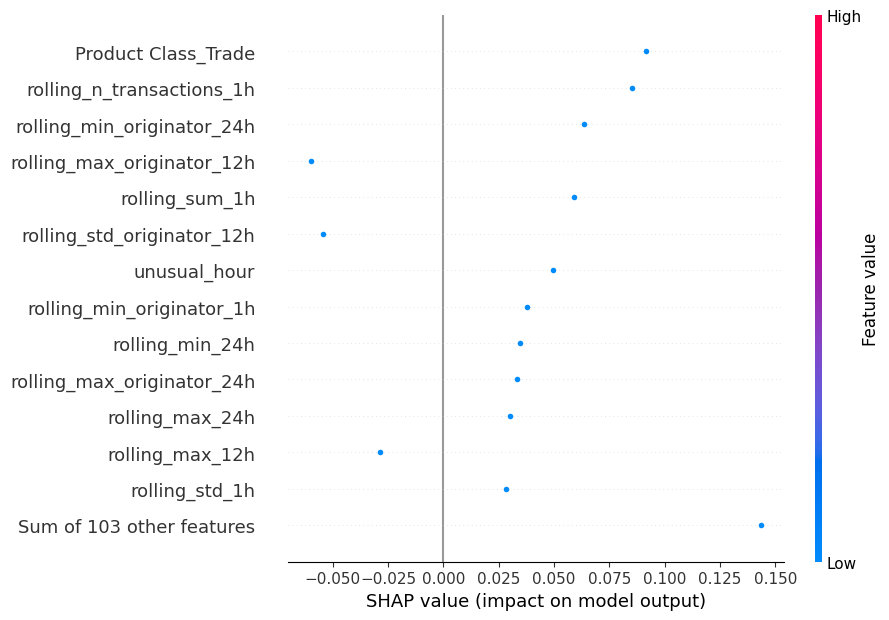

<Figure size 640x480 with 0 Axes>

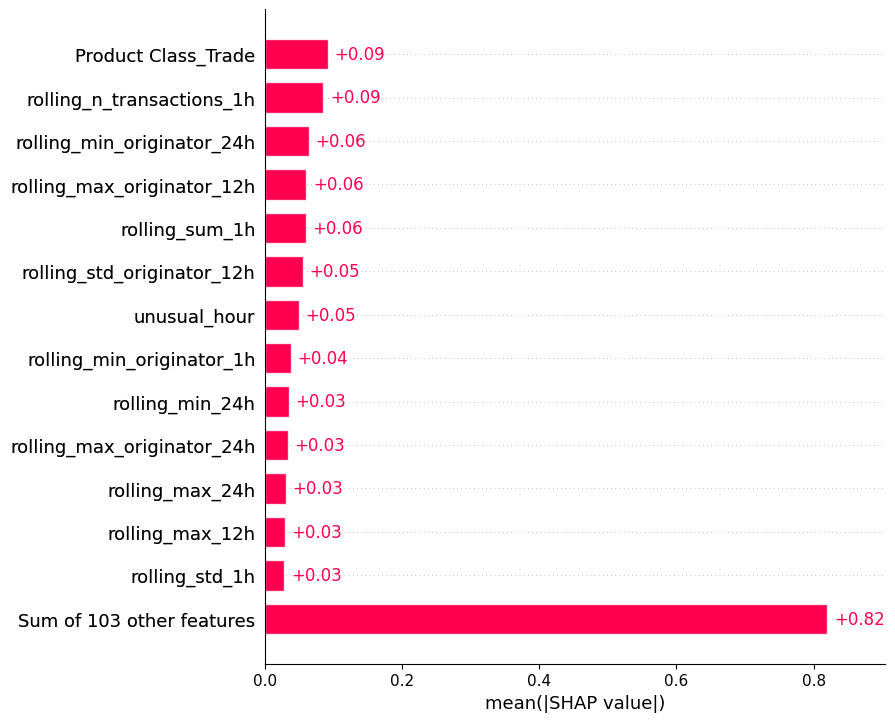

Saved SHAP plots for class 3 to output/shap_plots/
SHAP explanations generated and saved.


In [472]:
X_train_shap, _, _ = sample_data(X_train, y_train, n_samples=3000, anomaly_ratio=0.3, random_seed=42)
get_shap_explanations_mlp_class(model, X_train_shap, x.reshape(1, -1), feature_names, filename='figs/shap_plots/shap_amaretto_GM')

In [311]:
imp_features = [feature_names[idx] for idx in sorted_importance[:10]]
print(imp_features)
df_test.filter(pl.col('index') == idx).select(imp_features)

['Product Class_Cash in / out (withdrawal), Security in / out', 'Product Type_SimpleTransfer', 'Product Class_freq_originator', 'Product Type_freq_originator', 'product_type_index_timestamp_diff_2', 'originator_index_timestamp_diff_1', 'InputOutput_Buy', 'Product Type_FX', 'Product Type_Repo', 'rolling_std_originator_7d']


"Product Class_Cash in / out (withdrawal), Security in / out",Product Type_SimpleTransfer,Product Class_freq_originator,Product Type_freq_originator,product_type_index_timestamp_diff_2,originator_index_timestamp_diff_1,InputOutput_Buy,Product Type_FX,Product Type_Repo,rolling_std_originator_7d
u8,u8,f64,f64,f64,f64,u8,u8,u8,f64
1,1,0.250974,2.169715,-0.917766,2.693323,0,0,0,-0.102153


In [484]:
#idx = 2191351

sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[  1 110  99  71  73 112  42  36  65  59]
num of non-zero features: 12
InputOutput_Buy: -0.7897551360683237
InputOutput_freq_originator: 0.5536761023117561
rolling_sum_originator_24h: 0.03485049300505521
rolling_max_24h: 0.03133015445680192
rolling_min_1h: 0.023800474295568714
Product Type_freq_originator: 0.022310920403735265
product_type_index_timestamp_diff_2: -0.021152407656403017
market_index_timestamp_diff_1: 0.005544440265972077
rolling_std_1h: 0.005470035253254482
rolling_mean_24h: -0.0019606410366924598


[ 4837  2078  9758 26386 24820]


Using 2998 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 116, 6)
3


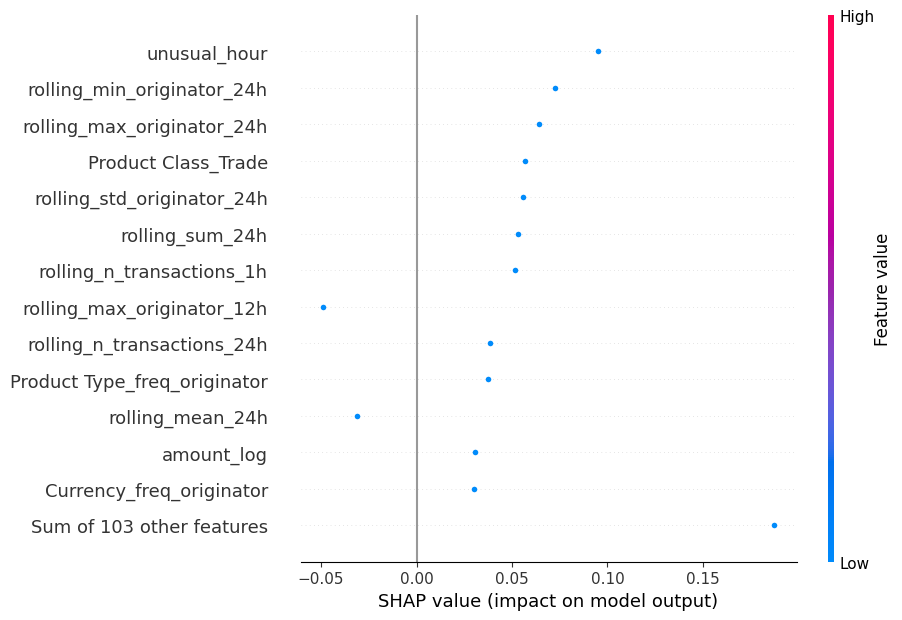

<Figure size 640x480 with 0 Axes>

Saved SHAP plots for class 3 to output/shap_plots/
SHAP explanations generated and saved.


In [493]:
X_train_shap, _, _ = sample_data(X_train, y_train, n_samples=3000, anomaly_ratio=0.3, random_seed=42)
get_shap_explanations_mlp_class(model, X_train_shap, x.reshape(1, -1), feature_names, filename='figs/shap_plots/shap_amaretto_GM')

  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 116, 6)
3


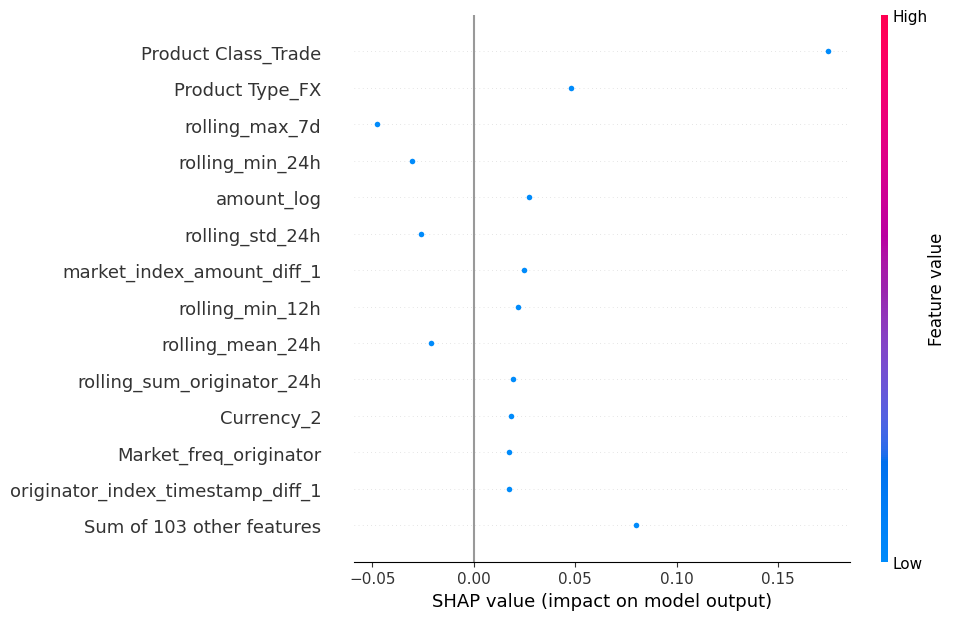

<Figure size 640x480 with 0 Axes>

Saved SHAP plots for class 3 to output/shap_plots/
SHAP explanations generated and saved.


In [494]:
get_shap_explanations_mlp_class(model, lasso_x_train, x.reshape(1, -1), feature_names, filename='figs/shap_plots/shap_amaretto_GM')

## 2.4. Large asset withdrawal:
A sudden spike in transaction amount withdrawn from an account or transferred out, which deviates from the previous transactional activity and is absent of any commercial rationale or related corporate action event.  

In [533]:
anomaly_type = 4
idx = 16483
X_train_a = X_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(X_train_a.shape)
print(y_train_a.shape)

(59757, 116)
(59757,)


In [534]:
x = X_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

(1, 116)
[[0.46960018 0.         1.         0.         0.         0.        ]]
4
4


In [535]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator,unusual_hour
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
16483,4,27012263,2019-03-18 07:21:58,"""Client_066""",4,1,0.4696,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,1,18,7,21,false,2.694239,1.938699,1.604809,1.429475,1.326425,0.874352,3.617136,9.14322,0.0,0.0,1.037095,-0.917766,-0.698787,-0.576665,-0.484611,-0.433523,-0.183119,-0.071133,0.0,0.0,-1.023369,1.803247,1.229654,0.000056,0.71708,1.365456,0.513469,-1.287407,-1.409974,1.270989,-1.224723,-0.707304,-0.280875,-1.4086,-1.684538,-0.895477,-1.64794,-3.436

In [536]:
lasso_x_train, lasso_y_train = find_knn(x, X_train_n, y_train_n, X_train_a, y_train_a, k=9)

(18, 116)
(18,)


In [537]:
lasso_classifier = Lasso(alpha=0.01)
lasso_classifier.fit(lasso_x_train, lasso_y_train)

Lasso(alpha=0.01)

In [538]:
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[  1  25 113 110  96  76  58  54  92  94]
num of non-zero features: 15
InputOutput_Buy: -3.16688938613936
Product Class_Cash in / out (withdrawal), Security in / out: 2.044909412046212
Product Class_freq_originator: 0.9159875013199048
InputOutput_freq_originator: -0.18240117559198252
rolling_min_originator_7d: -0.03634878526018163
rolling_min_7d: 0.03328939165106746
rolling_mean_12h: 0.030737390516038323
product_class_index_amount_diff_1: -0.02656407903019522
rolling_max_originator_7d: -0.025668846897327645
rolling_min_originator_12h: -0.01530941880998188


In [539]:
y_pred = lasso_classifier.predict(x)
print(y_pred)
print('R squared training set', lasso_classifier.score(lasso_x_train, lasso_y_train))

[3.94512875]
R squared training set 0.9988172960323373


In [540]:
imp_features = [feature_names[idx] for idx in sorted_importance[:10]]
print(imp_features)
df_test.filter(pl.col('index') == idx).select(imp_features)

['InputOutput_Buy', 'Product Class_Cash in / out (withdrawal), Security in / out', 'Product Class_freq_originator', 'InputOutput_freq_originator', 'rolling_min_originator_7d', 'rolling_min_7d', 'rolling_mean_12h', 'product_class_index_amount_diff_1', 'rolling_max_originator_7d', 'rolling_min_originator_12h']


InputOutput_Buy,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_freq_originator,InputOutput_freq_originator,rolling_min_originator_7d,rolling_min_7d,rolling_mean_12h,product_class_index_amount_diff_1,rolling_max_originator_7d,rolling_min_originator_12h
u8,u8,f64,f64,f64,f64,f64,f64,f64,f64
0,1,0.252304,5.883999,0.832207,-0.372707,-1.4086,0.000056,0.846607,1.795065


Using 2998 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 116, 6)
4


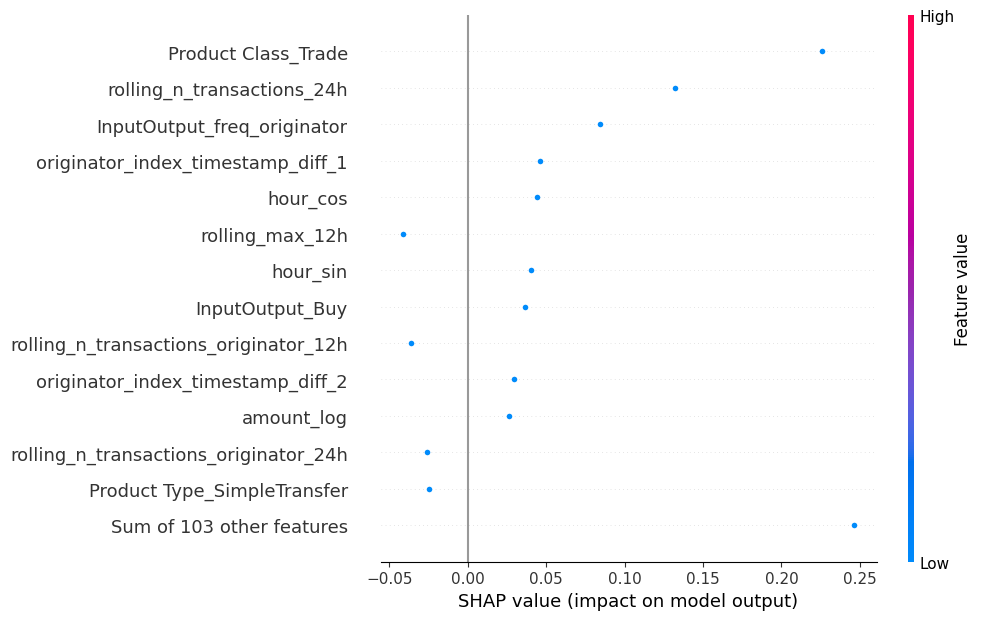

<Figure size 640x480 with 0 Axes>

Saved SHAP plots for class 4 to output/shap_plots/
SHAP explanations generated and saved.


In [541]:
get_shap_explanations_mlp_class(model, X_train_shap, x, feature_names, filename='figs/shap_plots/shap_amaretto_GM')


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 116, 6)
4


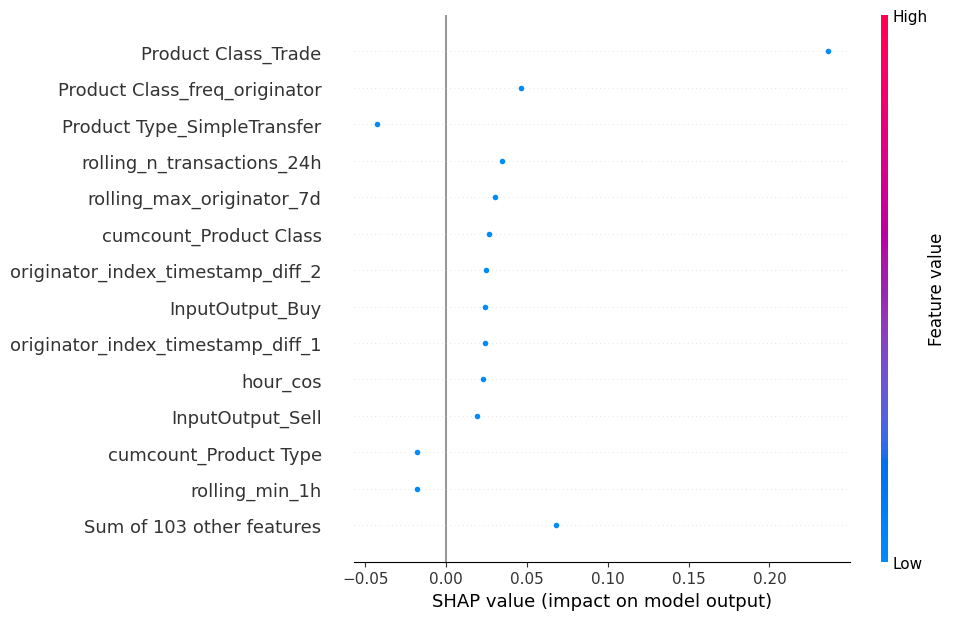

<Figure size 640x480 with 0 Axes>

Saved SHAP plots for class 4 to output/shap_plots/
SHAP explanations generated and saved.


In [542]:
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_amaretto_GM')


## 2.5. An unusually large amount of collateral transferred in and out of an account within a short period of time:
This behavior is unusual as a client would not be able to invest by simply trading collateral, or at least such a strategy would be unusual.  


In [543]:
idx = 37661 #2762376
#idx = 2762376

anomaly_type = 5
X_train_a = X_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(X_train_a.shape)
print(y_train_a.shape)

(124913, 116)
(124913,)


In [544]:
x = X_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

(1, 116)
[[-0.05676139  1.          0.          1.          0.          0.        ]]
5
5


In [371]:
df_correct_preds.filter(pl.col("index") == 2762376)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator,unusual_hour
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
2762376,5,29315121,2019-03-25 20:57:30,"""Client_066""",5,1,0.313846,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,1,25,20,57,false,2.722976,1.960468,1.622718,1.445076,1.340454,-0.669069,-0.284955,-0.112912,0.0,0.0,1.04478,-0.917766,-0.698787,-0.576665,-0.484611,2.420729,-0.183119,-0.071133,0.0,0.0,0.742409,-0.000208,-1.474181,-2.09058,0.71708,1.365456,1.493561,0.276227,1.227968,1.900558,0.575268,1.291715,-0.404574,-0.763154,-0.902047,-0.807294,-0.01851,

In [162]:
df_correct_preds.filter(pl.col("index") == 37661)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
37661,5,27267059,2019-03-18 08:00:06,"""Client_269""",5,1,-0.056761,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,18,8,0,false,2.706488,1.947968,1.612474,1.436145,1.332426,-0.669069,-0.284955,-0.112912,0.0,0.0,1.097752,1.392918,1.733295,2.015149,-0.484611,2.410997,-0.183119,-0.071133,0.0,0.0,-0.984395,-0.000208,1.113591,-2.277635,0.71708,1.365456,0.513469,-1.287407,-1.364252,0.64142,0.147873,1.40623,0.540915,0.35138,0.392118,-0.925693,0.136732,-2.270245,-3.718484,0.204,

In [545]:
lasso_x_train, lasso_y_train = find_knn(x, X_train_n, y_train_n, X_train_a, y_train_a, k=21)

(42, 116)
(42,)


In [547]:
lasso_classifier = Lasso(alpha=0.01)
lasso_classifier.fit(lasso_x_train, lasso_y_train)

Lasso(alpha=0.01)

In [394]:
# id = 2762376
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[ 25  10  36  23  13   5 112  22   9   4]
num of non-zero features: 35
Product Class_Cash in / out (withdrawal), Security in / out: 5.000815819451526
Product Type_ETOEquity: 0.8044833605493287
market_index_timestamp_diff_1: -0.33708989448500754
Product Type_SimpleTransfer: -0.21848285609093265
Product Type_FX: -0.11506644273481503
Market_3: 0.09109718566323399
Product Type_freq_originator: 0.08362567669841424
Product Type_Repo: -0.06114456477015142
Product Type_CAADR: 0.04910732995319412
Market_2: 0.03808443396638724


In [548]:
# id = 37661
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[ 34  15  25 100  61  26  18  91  14  96]
num of non-zero features: 35
originator_index_timestamp_diff_4: 3.7210019981579974
Product Type_FXSwap: -3.4428023326049075
Product Class_Cash in / out (withdrawal), Security in / out: 3.3273082041456585
rolling_sum_originator_7d: -2.177303076308097
rolling_sum_1h: -1.2458739177938574
Product Class_External fee: -1.2378698257017215
Product Type_FutureEquity: 1.115770357435221
rolling_max_originator_24h: 1.0537463637717412
Product Type_FXForward: -0.9629200756528762
rolling_min_originator_7d: 0.9308012814149832


Using 2998 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 116, 6)
5


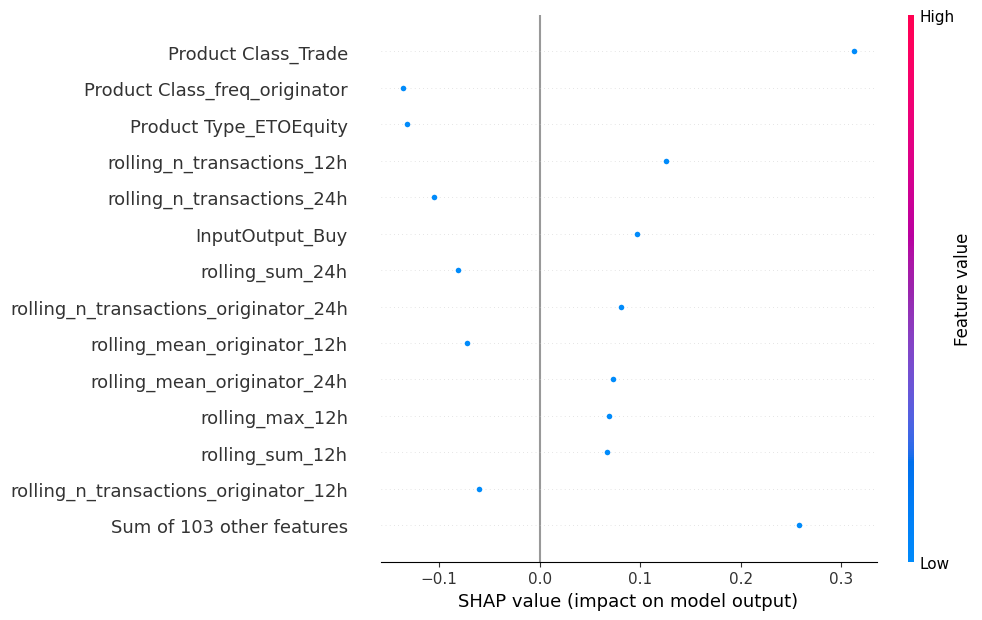

<Figure size 640x480 with 0 Axes>

Saved SHAP plots for class 5 to output/shap_plots/
SHAP explanations generated and saved.


In [549]:
get_shap_explanations_mlp_class(model, X_train_shap, x, feature_names, filename='figs/shap_plots/shap_amaretto_GM')


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 116, 6)
5


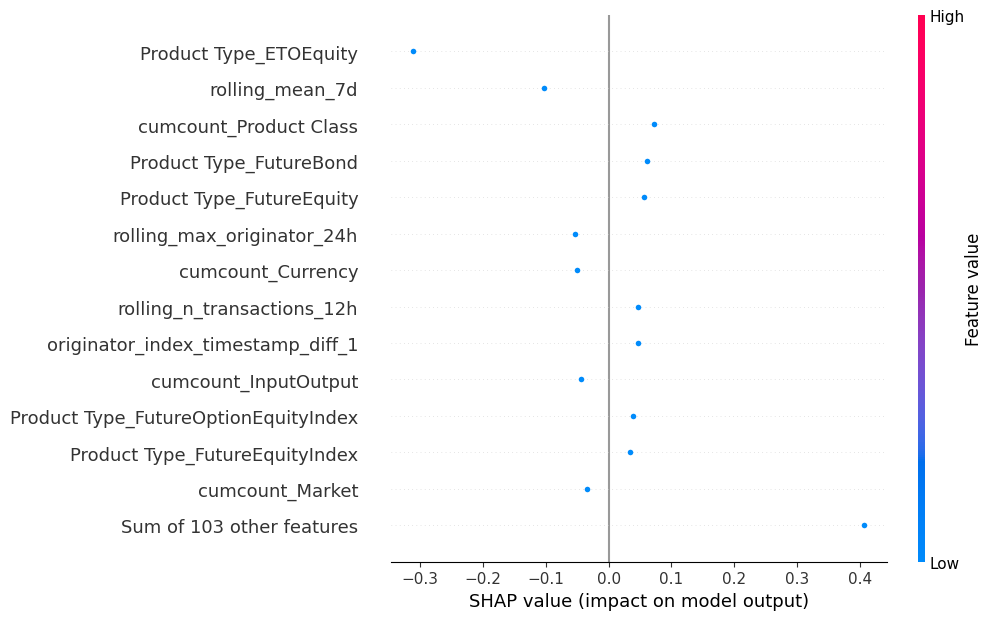

<Figure size 640x480 with 0 Axes>

Saved SHAP plots for class 5 to output/shap_plots/
SHAP explanations generated and saved.


In [550]:
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_amaretto_GM')


In [375]:
y_pred = lasso_classifier.predict(x)
print(y_pred)
print('R squared training set', lasso_classifier.score(lasso_x_train, lasso_y_train))

[4.99528603]
R squared training set 0.9998722962155524


In [395]:
# index = 2762376
imp_features = [feature_names[idx] for idx in sorted_importance[:10]]
print(imp_features)
df_test.filter(pl.col('index') == idx).select(imp_features)

['Product Class_Cash in / out (withdrawal), Security in / out', 'Product Type_ETOEquity', 'market_index_timestamp_diff_1', 'Product Type_SimpleTransfer', 'Product Type_FX', 'Market_3', 'Product Type_freq_originator', 'Product Type_Repo', 'Product Type_CAADR', 'Market_2']


"Product Class_Cash in / out (withdrawal), Security in / out",Product Type_ETOEquity,market_index_timestamp_diff_1,Product Type_SimpleTransfer,Product Type_FX,Market_3,Product Type_freq_originator,Product Type_Repo,Product Type_CAADR,Market_2
u8,u8,f64,u8,u8,u8,f64,u8,u8,u8
1,0,-0.669069,0,0,0,0.263391,1,0,1


In [168]:
# idx = 37661
imp_features = [feature_names[idx] for idx in sorted_importance[:10]]
print(imp_features)
df_test.filter(pl.col('index') == idx).select(imp_features)

['Product Type_FutureEquity', 'rolling_std_24h', 'Product Class_Cash in / out (withdrawal), Security in / out', 'Product Type_Bond', 'rolling_n_transactions_originator_24h', 'InputOutput_freq_originator', 'product_class_index_timestamp_diff_1', 'originator_index_timestamp_diff_1', 'product_type_index_timestamp_diff_4', 'originator_index_amount_diff_1']


Product Type_FutureEquity,rolling_std_24h,"Product Class_Cash in / out (withdrawal), Security in / out",Product Type_Bond,rolling_n_transactions_originator_24h,InputOutput_freq_originator,product_class_index_timestamp_diff_1,originator_index_timestamp_diff_1,product_type_index_timestamp_diff_4,originator_index_amount_diff_1
u8,f64,u8,u8,f64,f64,f64,f64,f64,f64
0,0.267433,1,0,-2.395277,0.542062,2.410997,2.706488,2.015149,-0.984395


# 3. Explanations on latent space

In [569]:
z_train_n = z_train[y_pred_train == 0]
y_train_n = y_pred_train[y_pred_train == 0]
print(z_train_n.shape)
print(y_train_n.shape)

(24218980, 16)
(24218980,)


## 3.1. Small but highly frequent transactions generated within a short timeframe:
A pattern that contains multiple transactions below applicable reporting thresholds.  

In [565]:
anomaly_type = 1
#idx = 8357	
#idx = 47208
#idx = 59510
idx = 51542
k = 9

In [566]:
z_train_a = z_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(z_train_a.shape)
print(y_train_a.shape)

(26277, 16)
(26277,)


In [567]:
x = torch.tensor(X_test[idx], dtype=torch.float32).reshape(1, -1)
#x = X_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

model.encoder.eval()
test_transaction_latent = model.encoder(x)
test_transaction_latent = test_transaction_latent.cpu().detach().numpy()
test_transaction_latent = test_transaction_latent.reshape(1, -1)
test_transaction_latent.shape

torch.Size([1, 116])
tensor([[-1.3714,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000]])
1
1


(1, 16)

In [568]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator,unusual_hour
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
51542,1,27058562,2019-03-18 08:24:40,"""Client_066""",1,1,-1.371359,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,18,8,24,false,2.694396,1.938846,1.604932,1.429586,1.326514,1.661105,3.638817,-0.112912,0.0,0.0,1.037146,-0.917766,-0.698787,-0.576665,-0.484611,2.411019,-0.183119,-0.071133,0.0,0.0,-1.048637,0.904308,0.637151,-2.355892,0.71708,1.365456,0.513469,-1.287407,-1.364252,0.64142,-0.946266,-1.051156,0.633959,0.362843,0.405643,-0.895847,0.14669,-1.8

In [401]:
knn_normal = NearestNeighbors(n_neighbors=k, algorithm='auto', metric='euclidean')
knn_normal.fit(z_train_n)
distances_n, indices_n = knn_normal.kneighbors(test_transaction_latent, n_neighbors=k)
print(indices_n)
print(distances_n)

knn_anomaly = NearestNeighbors(n_neighbors=k, algorithm='auto', metric='euclidean')
knn_anomaly.fit(z_train_a)
distances_a, indices_a = knn_anomaly.kneighbors(test_transaction_latent, n_neighbors=k)
print(indices_a)
print(distances_a)

[[ 8469041   786623 14386848 16456170  1653971 14270323  2600641  6884144
    637531]]
[[5.34924221 5.54619646 5.6588006  5.72003078 5.72298956 5.72617292
  5.77509403 5.79466438 5.8052392 ]]
[[ 5630  5573 13153 12428  5596  5594 13160  5592  4047]]
[[1.00450015 1.06799412 1.07400823 1.0847646  1.17012119 1.17083704
  1.22067535 1.24128497 1.25460839]]


In [402]:
lasso_x_train = np.vstack((z_train_n[indices_n.flatten().tolist()], z_train_a[indices_a.flatten().tolist()]))
lasso_y_train = np.concatenate((y_train_n[indices_n.flatten().tolist()], y_train_a[indices_a.flatten().tolist()]))

print(lasso_x_train.shape)
print(lasso_y_train.shape)

(18, 16)
(18,)


In [403]:
lasso_classifier = Lasso(alpha=0.05)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

[ 0.0273791   0.         -0.10534227  0.         -0.          0.
 -0.         -0.         -0.          0.          0.19681309 -0.
  0.         -0.         -0.10328226  0.        ]


In [195]:
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[ 4  7 13  8 10  0 11  1 15  9]
z_4: -2.842630624771118
z_7: -1.797913908958435
z_13: -1.7776914834976196
z_8: -0.8401194214820862
z_10: 0.7909547090530396
z_0: -0.6901487708091736
z_11: -0.5478876233100891
z_1: 0.5196952819824219
z_15: -0.3222387135028839
z_9: -0.0


In [381]:
#idx = 47208
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[13 14 10  4 12 11  9 15  8  7]
z_13: -0.399502694606781
z_14: -0.183762788772583
z_10: 0.12452422827482224
z_4: -0.0983685553073883
z_12: 0.0
z_11: -0.0
z_9: 0.0
z_15: -0.0
z_8: -0.0
z_7: -0.0


In [397]:
#idx = 59510
# 59510 a 47208 - stejny klient - vysvetleni jsou podobna
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[13 14 10 15 12 11  9  8  7  6]
z_13: -0.624029815196991
z_14: -0.10480958968400955
z_10: 0.057289741933345795
z_15: 0.0
z_12: -0.0
z_11: -0.0
z_9: 0.0
z_8: -0.0
z_7: -0.0
z_6: 0.0


In [404]:
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[10  2 14  0 12 11 13 15  8  9]
z_10: 0.19681309163570404
z_2: -0.10534226894378662
z_14: -0.10328225791454315
z_0: 0.027379101142287254
z_12: 0.0
z_11: -0.0
z_13: -0.0
z_15: 0.0
z_8: -0.0
z_9: 0.0


In [197]:
y_pred = lasso_classifier.predict(test_transaction_latent)
print(y_pred)
print('R squared training set', lasso_classifier.score(lasso_x_train, lasso_y_train))

[3.9602852]
R squared training set 0.7354124784469604


## 3.2. Transactions with rounded normalized amounts bought or sold within an account:
It is unusual for transactions in capital markets to have rounded amounts (unless they occur in markets where foreign exchange conversion causes rounding errors).  


In [253]:
anomaly_type = 2
idx = 2762998
#idx = 8891
#idx = 9186

In [254]:
z_train_a = z_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(z_train_a.shape)
print(y_train_a.shape)

(3075, 16)
(3075,)


In [255]:
x = torch.tensor(X_test[idx], dtype=torch.float32).reshape(1, -1)
#x = X_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

model.encoder.eval()
test_transaction_latent = model.encoder(x)
test_transaction_latent = test_transaction_latent.cpu().detach().numpy()
test_transaction_latent = test_transaction_latent.reshape(1, -1)
test_transaction_latent.shape

torch.Size([1, 121])
tensor([[-0.1537,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000]])
2
2


(1, 16)

In [256]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2762998,2,29358356,2019-03-25 20:58:44,"""Client_126""",2,1,-0.153726,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,25,20,58,true,1.976088,1.405621,1.183206,1.062452,0.996917,1.666501,-0.284955,-0.112912,0.0,0.0,-1.390533,-0.917766,-0.698787,-0.576665,-0.484611,-0.433523,-0.183119,-0.071133,0.0,0.0,-0.92282,-1.812988,-0.000167,0.000056,0.71708,1.365456,1.493561,0.276227,1.227968,1.900558,0.437069,1.344762,-0.20075,-0.763227,-0.89009,-0.796219,-0.016536,1.158688,0.548016

In [257]:
knn_normal = NearestNeighbors(n_neighbors=k, algorithm='auto', metric='euclidean')
knn_normal.fit(z_train_n)
distances_n, indices_n = knn_normal.kneighbors(test_transaction_latent, n_neighbors=k)
print(indices_n)
print(distances_n)

knn_anomaly = NearestNeighbors(n_neighbors=k, algorithm='auto', metric='euclidean')
knn_anomaly.fit(z_train_a)
distances_a, indices_a = knn_anomaly.kneighbors(test_transaction_latent, n_neighbors=k)
print(indices_a)
print(distances_a)

[[ 7024447 16785908 15389272 17173201 18709443  1985380 13342260 10973830
  22879734]]
[[2.38548064 2.74158287 2.77904725 2.78241467 2.7916584  2.81790018
  2.83059764 2.8639226  2.88578558]]
[[2003 1680 2585 2584 2852 2334 2028 2609 2331]]
[[1.31661534 1.47595024 1.56430936 1.58656859 1.62715888 1.63853288
  1.68013847 1.69776201 1.70690382]]


In [258]:
lasso_x_train = np.vstack((z_train_n[indices_n.flatten().tolist()], z_train_a[indices_a.flatten().tolist()]))
lasso_y_train = np.concatenate((y_train_n[indices_n.flatten().tolist()], y_train_a[indices_a.flatten().tolist()]))

print(lasso_x_train.shape)
print(lasso_y_train.shape)

(18, 16)
(18,)


In [214]:
# idx = 8891
lasso_classifier = Lasso(alpha=0.1)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

[-0.          0.         -0.         -0.         -0.11740979  0.
  0.         -0.         -0.          0.14261469  0.         -0.
 -0.          0.         -0.59548354 -0.        ]


In [251]:
#idx = 9186
lasso_classifier = Lasso(alpha=0.1)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

[-0.          0.         -0.         -0.         -0.04059238  0.
  0.         -0.         -0.          0.07508865  0.         -0.
 -0.          0.06717732 -0.67675436 -0.        ]


In [259]:
#idx = 2762998
lasso_classifier = Lasso(alpha=0.1)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

[-0.          0.          0.          0.4288372  -0.21016456 -0.
  0.         -0.         -0.          0.          0.07228045 -0.
 -0.          0.         -0.7131233   0.        ]


In [218]:
# idx = 8891
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[14  9  4 13 12 11 10 15  8  7]
z_14: -0.5954835414886475
z_9: 0.1426146924495697
z_4: -0.11740978807210922
z_13: 0.0
z_12: -0.0
z_11: -0.0
z_10: 0.0
z_15: -0.0
z_8: -0.0
z_7: -0.0


In [252]:
#idx = 9186
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[14  9 13  4 12 11 10 15  8  7]
z_14: -0.676754355430603
z_9: 0.07508864998817444
z_13: 0.06717731803655624
z_4: -0.04059237986803055
z_12: -0.0
z_11: -0.0
z_10: 0.0
z_15: -0.0
z_8: -0.0
z_7: -0.0


In [261]:
#idx = 2762998
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[14  3  4 10 12 11 13 15  8  9]
z_14: -0.7131233215332031
z_3: 0.42883720993995667
z_4: -0.21016456186771393
z_10: 0.07228045165538788
z_12: -0.0
z_11: -0.0
z_13: 0.0
z_15: 0.0
z_8: -0.0
z_9: 0.0


In [217]:
y_pred = lasso_classifier.predict(test_transaction_latent)
print(y_pred)
print('R squared training set', lasso_classifier.score(lasso_x_train, lasso_y_train))

[1.8182106]
R squared training set 0.9356386065483093


## 3.3. Security bought or sold at an unusual time:
It is unusual for clients to trade specific securities outside of a specific timeframe (for example, outside of the opening and closing times of a stock exchange).  


In [295]:
anomaly_type = 3
#idx = 1260		
#idx = 1157
idx = 2191296
z_train_a = z_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(z_train_a.shape)
print(y_train_a.shape)

(11425, 16)
(11425,)


In [296]:
x = torch.tensor(X_test[idx], dtype=torch.float32).reshape(1, -1)
#x = X_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

model.encoder.eval()
test_transaction_latent = model.encoder(x)
test_transaction_latent = test_transaction_latent.cpu().detach().numpy()
test_transaction_latent = test_transaction_latent.reshape(1, -1)
test_transaction_latent.shape

torch.Size([1, 121])
tensor([[0.4377, 0.0000, 1.0000, 1.0000, 0.0000, 0.0000]])
3
3


(1, 16)

In [297]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2191296,3,29582320,2019-03-25 04:55:24,"""Client_066""",3,1,0.437687,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,1,25,4,55,false,2.720786,1.958762,1.621336,1.443876,1.339378,-0.669069,-0.284955,-0.112912,0.0,0.0,-1.390533,-0.917766,-0.698787,-0.576665,-0.484611,-0.433523,-0.183119,-0.071133,0.0,0.0,1.014191,-0.000208,-0.000167,0.000056,0.71708,1.365456,1.493561,0.276227,-1.016961,2.991005,0.831314,1.143892,4.9937,7.037661,8.281472,-0.384886,-6.23429,-5.238993,-7.187119,

In [298]:
knn_normal = NearestNeighbors(n_neighbors=k, algorithm='auto', metric='euclidean')
knn_normal.fit(z_train_n)
distances_n, indices_n = knn_normal.kneighbors(test_transaction_latent, n_neighbors=k)
print(indices_n)
print(distances_n)

knn_anomaly = NearestNeighbors(n_neighbors=k, algorithm='auto', metric='euclidean')
knn_anomaly.fit(z_train_a)
distances_a, indices_a = knn_anomaly.kneighbors(test_transaction_latent, n_neighbors=k)
print(indices_a)
print(distances_a)

[[19181254  4550302 19181207  4550311  4550573 19181273  4551119  4549768
  19181228]]
[[2.00121045 2.05460787 2.06765532 2.07407093 2.07464314 2.09097219
  2.09130216 2.11779213 2.12236404]]
[[ 5888  4770  5929  5902  5856  5883  5868 10495  4838]]
[[1.13939023 1.14369786 1.3032707  1.35032642 1.36107588 1.36896372
  1.40083265 1.40411448 1.41559124]]


In [299]:
lasso_x_train = np.vstack((z_train_n[indices_n.flatten().tolist()], z_train_a[indices_a.flatten().tolist()]))
lasso_y_train = np.concatenate((y_train_n[indices_n.flatten().tolist()], y_train_a[indices_a.flatten().tolist()]))

print(lasso_x_train.shape)
print(lasso_y_train.shape)

(18, 16)
(18,)


In [300]:
lasso_classifier = Lasso(alpha=0.1)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

[ 0.         -0.          0.         -0.         -0.          0.
 -0.00651955 -0.          0.          0.          2.3100157   0.
 -0.          0.         -0.6542186   0.        ]


In [270]:
# idx = 1260
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[15  9 14 13 12 11 10  8  7  6]
z_15: 1.6302036046981812
z_9: 1.4055988788604736
z_14: -0.5636571645736694
z_13: 0.0
z_12: 0.0
z_11: 0.0
z_10: 0.0
z_8: -0.0
z_7: -0.0
z_6: -0.0


In [278]:
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[15  4  3  8 12 11 13 14  9 10]
z_15: 1.805695652961731
z_4: -1.358310580253601
z_3: 1.0342575311660767
z_8: 0.10734690725803375
z_12: -0.0
z_11: 0.0
z_13: 0.0
z_14: -0.0
z_9: 0.0
z_10: 0.0


In [301]:
#idx= 2191296
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[10 14  6 13 12 11  9 15  8  7]
z_10: 2.3100156784057617
z_14: -0.6542186141014099
z_6: -0.006519550457596779
z_13: 0.0
z_12: -0.0
z_11: 0.0
z_9: 0.0
z_15: 0.0
z_8: 0.0
z_7: -0.0


## 2.4. Large asset withdrawal:
A sudden spike in transaction amount withdrawn from an account or transferred out, which deviates from the previous transactional activity and is absent of any commercial rationale or related corporate action event.  


In [333]:
anomaly_type = 4
#idx = 16483
#idx = 43121
idx = 1578200
z_train_a = z_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(z_train_a.shape)
print(y_train_a.shape)

(60973, 16)
(60973,)


In [334]:
x = torch.tensor(X_test[idx], dtype=torch.float32).reshape(1, -1)
#x = X_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

model.encoder.eval()
test_transaction_latent = model.encoder(x)
test_transaction_latent = test_transaction_latent.cpu().detach().numpy()
test_transaction_latent = test_transaction_latent.reshape(1, -1)
test_transaction_latent.shape

torch.Size([1, 121])
tensor([[0.2837, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]])
4
4


(1, 16)

In [335]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1578200,4,28389041,2019-03-21 13:52:58,"""Client_126""",4,1,0.283702,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,4,21,13,52,false,1.868977,1.324096,1.099986,0.991582,0.93298,-0.669069,-0.284955,-0.112912,0.0,0.0,-1.390533,-0.917766,-0.698787,-0.576665,-0.484611,-0.433523,-0.183119,-0.071133,0.0,0.0,0.456582,-0.000208,-0.000167,0.000056,-0.1313,-1.087529,1.212389,-0.80366,-0.068142,-1.16148,1.144188,0.831028,-0.071814,-0.968032,-0.420084,-0.36045,0.033574,0.121585,0.3093

In [336]:
knn_normal = NearestNeighbors(n_neighbors=k, algorithm='auto', metric='euclidean')
knn_normal.fit(z_train_n)
distances_n, indices_n = knn_normal.kneighbors(test_transaction_latent, n_neighbors=k)
print(indices_n)
print(distances_n)

knn_anomaly = NearestNeighbors(n_neighbors=k, algorithm='auto', metric='euclidean')
knn_anomaly.fit(z_train_a)
distances_a, indices_a = knn_anomaly.kneighbors(test_transaction_latent, n_neighbors=k)
print(indices_a)
print(distances_a)

[[22637796  6515247 14918450 21045242 23973410 18005843 18596616 17494687
  24128359]]
[[2.09333301 2.20503902 2.21301699 2.23646998 2.27940512 2.28431606
  2.3295927  2.33245277 2.35924649]]
[[51779 51782 51854 51914 51770 51685 51789 51686 56578]]
[[0.6487757  0.66346639 0.7476024  0.81965625 0.82133055 0.83718187
  0.86397141 0.86418015 0.87199795]]


In [337]:
lasso_x_train = np.vstack((z_train_n[indices_n.flatten().tolist()], z_train_a[indices_a.flatten().tolist()]))
lasso_y_train = np.concatenate((y_train_n[indices_n.flatten().tolist()], y_train_a[indices_a.flatten().tolist()]))

print(lasso_x_train.shape)
print(lasso_y_train.shape)

(18, 16)
(18,)


In [338]:
lasso_classifier = Lasso(alpha=0.1)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

[-0.         -0.         -0.          0.68520284 -1.7985528   0.
 -0.         -0.         -0.          0.          0.         -0.51679516
  0.         -0.9433232  -0.         -0.39799213]


In [313]:
# idx = 16483
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[14  2 11 15 12 10  9 13  8  7]
z_14: -0.8668021559715271
z_2: -0.6827273368835449
z_11: -0.5504565238952637
z_15: -0.12361042946577072
z_12: 0.0
z_10: 0.0
z_9: 0.0
z_13: -0.0
z_8: 0.0
z_7: -0.0


In [330]:
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[11 15 13  3 14  0 12 10  8  9]
z_11: -1.0144938230514526
z_15: -0.3820912539958954
z_13: -0.20467519760131836
z_3: 0.18361549079418182
z_14: -0.13533329963684082
z_0: -0.08610198646783829
z_12: 0.0
z_10: 0.0
z_8: 0.0
z_9: -0.0


In [339]:
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[ 4 13  3 11 15 10 12 14  8  9]
z_4: -1.7985527515411377
z_13: -0.9433231949806213
z_3: 0.6852028369903564
z_11: -0.5167951583862305
z_15: -0.3979921340942383
z_10: 0.0
z_12: 0.0
z_14: -0.0
z_8: -0.0
z_9: 0.0


In [340]:
y_pred = lasso_classifier.predict(test_transaction_latent)
print(y_pred)
print('R squared training set', lasso_classifier.score(lasso_x_train, lasso_y_train))

[3.3733356]
R squared training set 0.9586156010627747


## 3.5. An unusually large amount of collateral transferred in and out of an account within a short period of time:
This behavior is unusual as a client would not be able to invest by simply trading collateral, or at least such a strategy would be unusual.   

In [361]:
# idx = 37661
# idx = 2762376
idx = 2742220
anomaly_type = 5
z_train_a = z_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(z_train_a.shape)
print(y_train_a.shape)

(68173, 16)
(68173,)


In [362]:
x = torch.tensor(X_test[idx], dtype=torch.float32).reshape(1, -1)
#x = X_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

model.encoder.eval()
test_transaction_latent = model.encoder(x)
test_transaction_latent = test_transaction_latent.cpu().detach().numpy()
test_transaction_latent = test_transaction_latent.reshape(1, -1)
test_transaction_latent.shape

torch.Size([1, 121])
tensor([[0.1276, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]])
5
5


(1, 16)

In [363]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2742220,5,29315163,2019-03-25 20:19:22,"""Client_066""",5,1,0.127558,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,25,20,19,false,2.722951,1.96039,1.622662,1.44503,1.340415,-0.669069,-0.284955,-0.112912,0.0,0.0,1.041646,1.371174,-0.698787,-0.576665,-0.484611,2.420702,-0.183119,-0.071133,0.0,0.0,-0.984276,-0.000208,-1.487097,-2.44517,0.71708,1.365456,1.493561,0.276227,1.227968,1.900558,-1.344977,-0.437218,-1.523585,-0.726696,-0.866729,-0.731116,0.209802,1.177584,0.490627

In [364]:
knn_normal = NearestNeighbors(n_neighbors=k, algorithm='auto', metric='euclidean')
knn_normal.fit(z_train_n)
distances_n, indices_n = knn_normal.kneighbors(test_transaction_latent, n_neighbors=k)
print(indices_n)
print(distances_n)

knn_anomaly = NearestNeighbors(n_neighbors=k, algorithm='auto', metric='euclidean')
knn_anomaly.fit(z_train_a)
distances_a, indices_a = knn_anomaly.kneighbors(test_transaction_latent, n_neighbors=k)
print(indices_a)
print(distances_a)

[[2224812 2445974 2486129 2863133 2452079 3157412 2840016 1799853  537756]]
[[3.30597401 3.36121106 3.45149326 3.50405145 3.50886726 3.53707814
  3.54500651 3.54833174 3.55391145]]
[[36947 64918 64916 64913 32603 29873 19184 32601 64888]]
[[0.73515326 0.8501938  0.88848692 0.93049419 0.94628245 0.96698058
  0.97500175 0.97839004 1.01206148]]


In [365]:
lasso_x_train = np.vstack((z_train_n[indices_n.flatten().tolist()], z_train_a[indices_a.flatten().tolist()]))
lasso_y_train = np.concatenate((y_train_n[indices_n.flatten().tolist()], y_train_a[indices_a.flatten().tolist()]))

print(lasso_x_train.shape)
print(lasso_y_train.shape)

(18, 16)
(18,)


In [366]:
lasso_classifier = Lasso(alpha=0.1)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

[ 0.          0.81061304 -0.          0.         -0.          0.
 -0.1136227  -0.         -0.9288145   0.          0.         -0.83087265
  1.3570399  -0.         -0.38097972 -0.        ]


In [348]:
# idx = 16483
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[ 4  7 13  8 10  0 11  1 15  9]
z_4: -2.842630624771118
z_7: -1.797913908958435
z_13: -1.7776914834976196
z_8: -0.8401194214820862
z_10: 0.7909547090530396
z_0: -0.6901487708091736
z_11: -0.5478876233100891
z_1: 0.5196952819824219
z_15: -0.3222387135028839
z_9: -0.0


In [356]:
#idx = 2762376
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[ 6  4  8  1 12 14 13 15  9 10]
z_6: -1.2893599271774292
z_4: -1.1086502075195312
z_8: -1.0477161407470703
z_1: 0.3213449716567993
z_12: 0.31699803471565247
z_14: -0.08331853151321411
z_13: -0.0
z_15: -0.0
z_9: 0.0
z_10: 0.0


In [367]:
#idx = 2742220
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[12  8 11  1 14  6 13 15  9 10]
z_12: 1.3570399284362793
z_8: -0.9288144707679749
z_11: -0.830872654914856
z_1: 0.8106130361557007
z_14: -0.3809797167778015
z_6: -0.11362269520759583
z_13: -0.0
z_15: -0.0
z_9: 0.0
z_10: 0.0


# 3. Knn on latent space, Explanations on input space

## 3.1. Small but highly frequent transactions generated within a short timeframe:
A pattern that contains multiple transactions below applicable reporting thresholds.  

In [ ]:
df_correct_preds.filter(pl.col("Anomaly") == 1)

In [572]:
anomaly_type = 1
#idx = 8357	
#idx = 47208
#idx = 59510
idx = 51542

In [573]:
z_train_a = z_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(z_train_a.shape)
print(y_train_a.shape)

(26277, 16)
(26277,)


In [577]:
x = torch.tensor(X_test[idx], dtype=torch.float32).reshape(1, -1)
#x = X_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

model.encoder.eval()
x = model.encoder(x)
x = x.cpu().detach().numpy()
x = x.reshape(1, -1)
x.shape

torch.Size([1, 116])
tensor([[-1.3714,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000]])
1
1


(1, 16)

In [575]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator,unusual_hour
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
51542,1,27058562,2019-03-18 08:24:40,"""Client_066""",1,1,-1.371359,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,18,8,24,false,2.694396,1.938846,1.604932,1.429586,1.326514,1.661105,3.638817,-0.112912,0.0,0.0,1.037146,-0.917766,-0.698787,-0.576665,-0.484611,2.411019,-0.183119,-0.071133,0.0,0.0,-1.048637,0.904308,0.637151,-2.355892,0.71708,1.365456,0.513469,-1.287407,-1.364252,0.64142,-0.946266,-1.051156,0.633959,0.362843,0.405643,-0.895847,0.14669,-1.8

In [584]:
lasso_x_train, lasso_y_train = find_knn_latent(x, X_train_n, z_train_n, y_train_n, X_train_a, z_train_a, y_train_a, k=21)

(42, 116)
(42,)


In [586]:
lasso_classifier = Lasso(alpha=0.01)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
#print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

Lasso(alpha=0.01)

In [589]:
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[109  69  60 104  37  81  71  82   4  36]
num of non-zero features: 24
cumcount_Currency: -0.16169879636163792
rolling_max_1h: -0.1312012012526254
rolling_mean_7d: 0.10052371957522449
rolling_n_transactions_originator_7d: -0.07322988300242912
market_index_timestamp_diff_2: -0.060552724938023966
rolling_mean_originator_1h: 0.056678842505183596
rolling_max_24h: -0.054301935363871026
rolling_mean_originator_12h: 0.0443745461619554
Market_2: 0.04398514344610679
market_index_timestamp_diff_1: 0.03981501786905011


## 4.2. Transactions with rounded normalized amounts bought or sold within an account:
It is unusual for transactions in capital markets to have rounded amounts (unless they occur in markets where foreign exchange conversion causes rounding errors).  


In [597]:
anomaly_type = 2
#idx = 2762998
idx = 8891

In [ ]:
#df_correct_preds.filter(pl.col("Anomaly") == 2)

In [599]:
z_train_a = z_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(z_train_a.shape)
print(y_train_a.shape)

(8768, 16)
(8768,)


In [600]:
x = torch.tensor(X_test[idx], dtype=torch.float32).reshape(1, -1)
#x = X_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

model.encoder.eval()
x = model.encoder(x)
x = x.cpu().detach().numpy()
x = x.reshape(1, -1)
x.shape

torch.Size([1, 116])
tensor([[-0.1902,  0.0000,  1.0000,  1.0000,  0.0000,  0.0000]])
2
2


(1, 16)

In [601]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator,unusual_hour
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
8891,2,27013699,2019-03-18 07:08:31,"""Client_066""",2,1,-0.190208,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,18,7,8,true,2.694246,1.938714,1.604807,1.429491,1.326428,-0.669069,-0.284955,-0.112912,0.0,0.0,-1.390533,-0.917766,-0.698787,-0.576665,-0.484611,-0.433523,-0.183119,-0.071133,0.0,0.0,0.89806,-0.000208,-0.000167,0.000056,0.71708,1.365456,0.513469,-1.287407,-1.409974,1.270989,-0.946266,1.050736,-1.469272,-3.17115,-3.764227,-0.91711,-3.313611,-

In [602]:
lasso_x_train, lasso_y_train = find_knn_latent(x, X_train_n, z_train_n, y_train_n, X_train_a, z_train_a, y_train_a, k=21)
lasso_classifier = Lasso(alpha=0.01)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
#print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

(42, 116)
(42,)


/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.098e-02, tolerance: 4.200e-03
  model = cd_fast.enet_coordinate_descent(


Lasso(alpha=0.01)

In [603]:
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[ 57 112   1  64  68  44  80  58  36  97]
num of non-zero features: 25
rolling_mean_1h: -0.19207314168273976
Product Type_freq_originator: -0.1850697412871615
InputOutput_Buy: 0.16733404490274034
rolling_sum_7d: -0.11450815696161314
rolling_std_7d: 0.11443683544820889
product_type_index_timestamp_diff_4: -0.08416105269935525
rolling_n_transactions_7d: -0.07962402982067901
rolling_mean_12h: 0.06100801871295049
market_index_timestamp_diff_1: -0.05109032740533671
rolling_sum_originator_1h: 0.04571162906957083


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 116, 6)
2


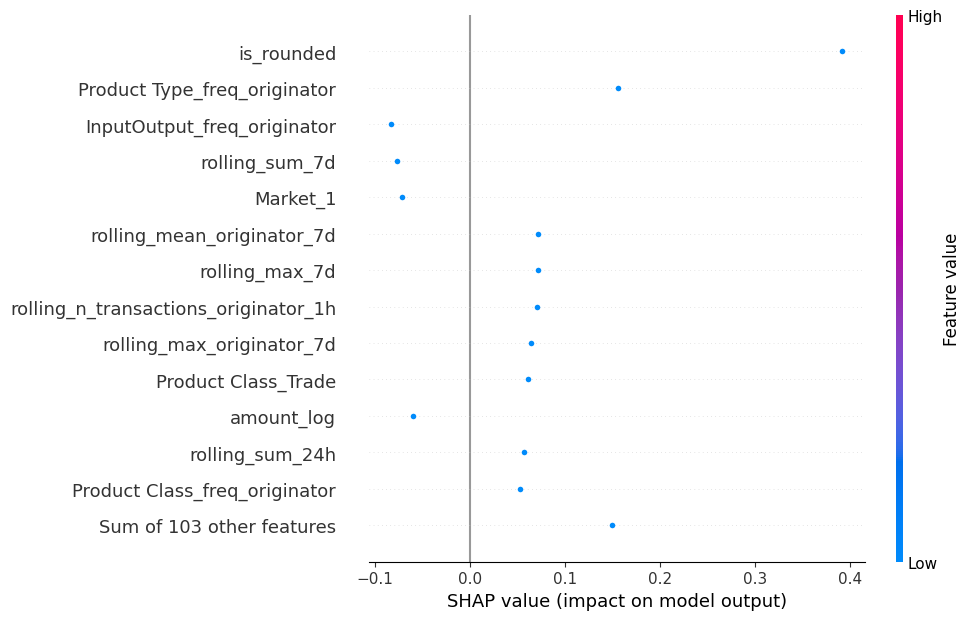

<Figure size 640x480 with 0 Axes>

Saved SHAP plots for class 2 to output/shap_plots/
SHAP explanations generated and saved.


In [604]:
x = X_test[idx].reshape(1, -1)
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_amaretto_GM')


## 4.3. Security bought or sold at an unusual time:
It is unusual for clients to trade specific securities outside of a specific timeframe (for example, outside of the opening and closing times of a stock exchange).  


In [4]:
anomaly_type = 3
idx = 1165
#idx = 2191351

In [5]:
z_train_a = z_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(z_train_a.shape)
print(y_train_a.shape)

NameError: name 'z_train' is not defined

In [ ]:
x = torch.tensor(X_test[idx], dtype=torch.float32).reshape(1, -1)
#x = X_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

model.encoder.eval()
x = model.encoder(x)
x = x.cpu().detach().numpy()
x = x.reshape(1, -1)
x.shape

In [ ]:
df_correct_preds.filter(pl.col("index") == idx)

In [ ]:
lasso_x_train, lasso_y_train = find_knn_latent(x, X_train_n, z_train_n, y_train_n, X_train_a, z_train_a, y_train_a, k=21)
lasso_classifier = Lasso(alpha=0.01)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
#print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

In [ ]:
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

In [ ]:
x = X_test[idx].reshape(1, -1)
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_amaretto_GM')


## 4.4. Large asset withdrawal:
A sudden spike in transaction amount withdrawn from an account or transferred out, which deviates from the previous transactional activity and is absent of any commercial rationale or related corporate action event.  

In [ ]:
anomaly_type = 4
idx = 16483


## 4.5. An unusually large amount of collateral transferred in and out of an account within a short period of time:
This behavior is unusual as a client would not be able to invest by simply trading collateral, or at least such a strategy would be unusual.  


In [ ]:
idx = 37661 #2762376
#idx = 2762376

anomaly_type = 5
